In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# <h1 style='text-align:center;'> Netflix </h1>

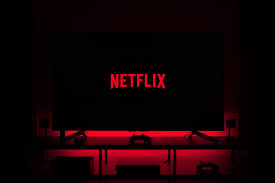

In [2]:
df = pd.read_csv("../input/netflix-shows/netflix_titles.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../input/netflix-shows/netflix_titles.csv'

In [ ]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

**Drop the nan values for visualization process **

In [ ]:
df = df.dropna()
print("The number of rows is {} and column is {}".format(df.shape[1], df.shape[0]))

The number of rows is 12 and column is 5332


In [ ]:
df.isna().sum() #Hurray  No null Values 

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator


There are 180887 words in the combination of all cells in column title.


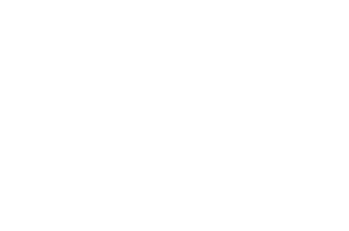

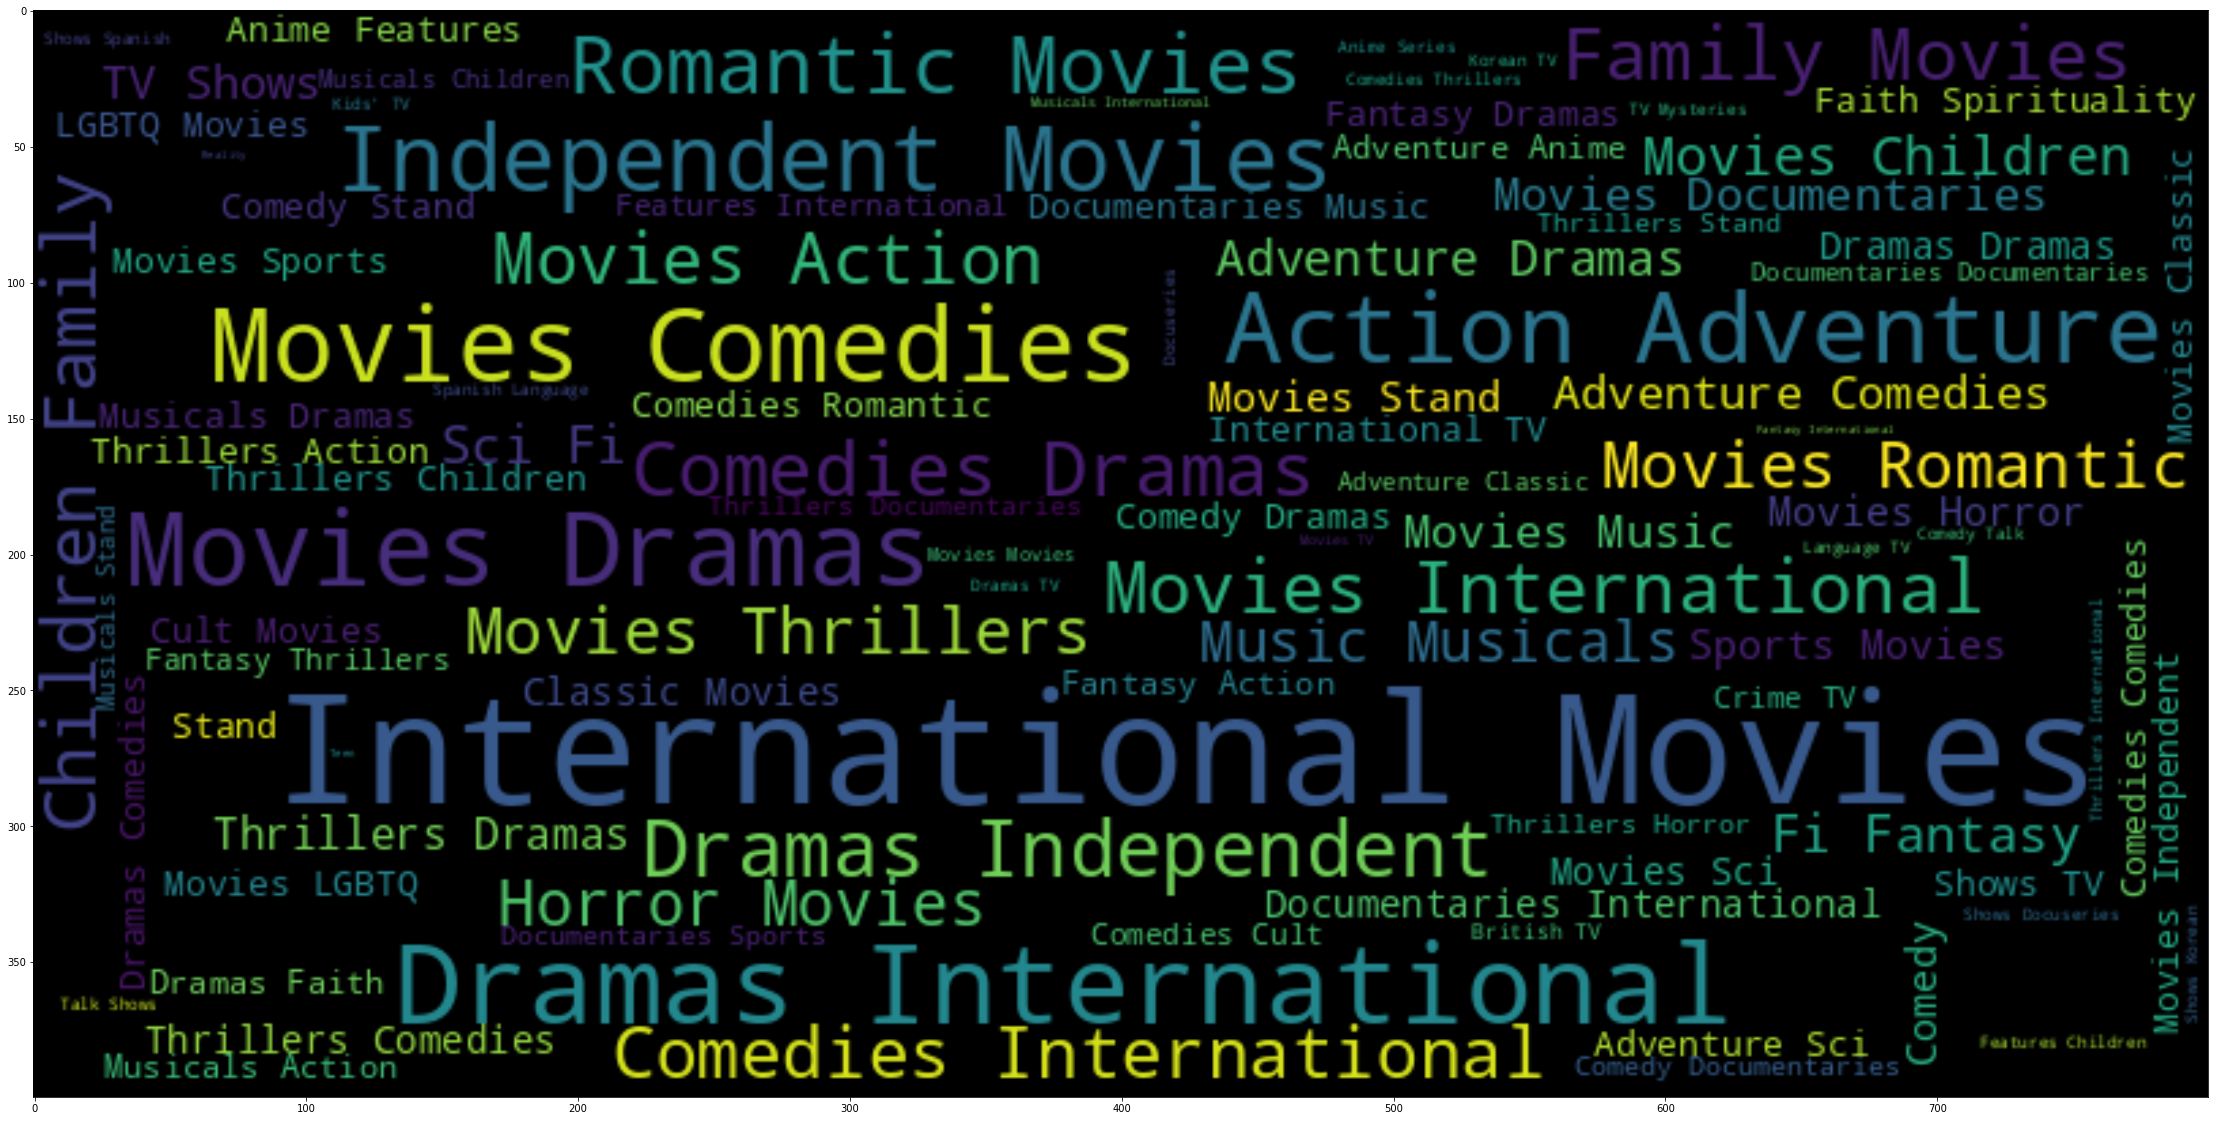

In [ ]:
text = " ".join(review for review in df.listed_in.astype(str))
print ("There are {} words in the combination of all cells in column title.".format(len(text)))


# Generate a word cloud image

wordcloud = WordCloud(background_color="black", width=800, height=400).generate(text)

# Display the generated image:
# the matplotlib way:

plt.axis("off")
plt.figure( figsize=(40,20))
plt.tight_layout(pad=0)
plt.imshow(wordcloud, interpolation='bilinear')
plt.show()

# Visualization

**Types**

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='type', ylabel='count'>

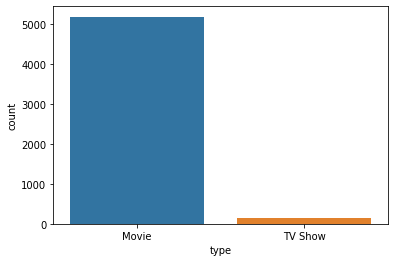

In [ ]:
sns.countplot(df['type'])

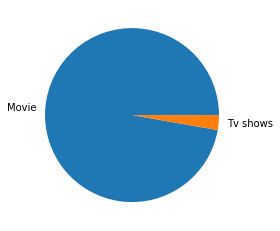

In [ ]:
labels = ["Movie", "Tv shows"]
plt.pie(df['type'].value_counts(), labels = labels)
plt.show()

In [ ]:
# Which director has make most movies and shows
df['director'].value_counts()

Raúl Campos, Jan Suter           18
Marcus Raboy                     15
Jay Karas                        14
Cathy Garcia-Molina              13
Martin Scorsese                  12
                                 ..
Igor Kovalyov, Norton Virgien     1
Danny Cannon                      1
Mana Yasuda                       1
Gupse Özay                        1
Mozez Singh                       1
Name: director, Length: 3945, dtype: int64

In [ ]:
df1 = df[df['director']=='Raúl Campos, Jan Suter']
df1.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4749,s4750,Movie,Coco y Raulito: Carrusel de ternura,"Raúl Campos, Jan Suter","Coco Celis, Raúl Meneses",Mexico,"July 27, 2018",2018,TV-MA,57 min,Stand-Up Comedy,"A study in contrasts, comedy partners and good..."


In [ ]:
df1.type.value_counts()

Movie    18
Name: type, dtype: int64

# Cast

**Which cast has work more**

In [ ]:
df2 = df.cast.value_counts().head(1)
df2.index.to_list()

['Samuel West']

In [ ]:
print("The cast has work more shows/movies are {}".format(df2.index.to_list()[0]))

The cast has work more shows/movies are Samuel West


**Top 5 countries which produce most movies/series**

In [ ]:
df3 =df['country'].value_counts().head(5)
df3

United States     1846
India              875
United Kingdom     183
Canada             107
Spain               91
Name: country, dtype: int64

<AxesSubplot:>

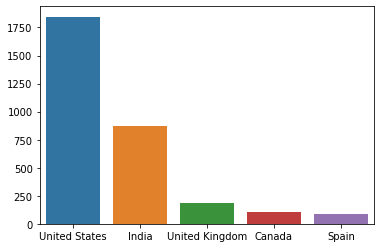

In [ ]:
sns.barplot(x=df3.index, y=df3.to_list())

# **Release Year**

**Top 10 years in which more movies release**

In [ ]:
df4 = df.release_year.value_counts().head(10)
df4

2017    657
2018    648
2016    577
2019    519
2020    442
2015    349
2014    242
2013    197
2012    163
2021    161
Name: release_year, dtype: int64

<AxesSubplot:>

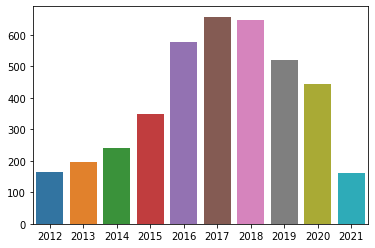

In [ ]:
sns.barplot(x=df4.index, y=df4.to_list())

<AxesSubplot:title={'center':'RELEASE RATEs'}>

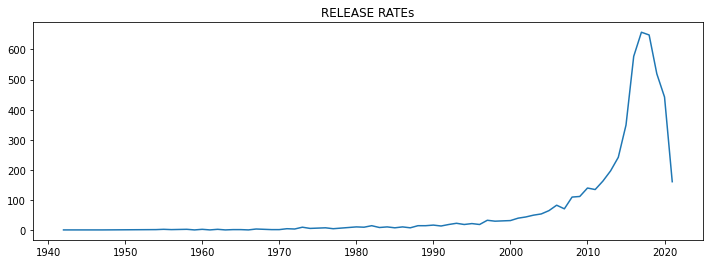

In [ ]:
plt.figure(figsize = (12,4))
rate_count = df['release_year'].value_counts()
plt.title("RELEASE RATEs")
sns.lineplot(x =rate_count.index , y= rate_count.values)

# Rating

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='rating', ylabel='count'>

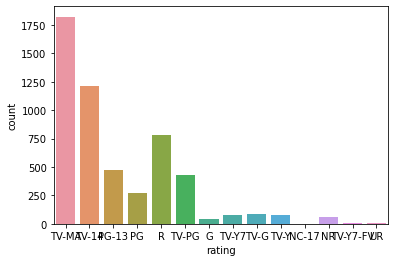

In [ ]:
sns.countplot(df.rating)

In [ ]:
df["rating"].unique()


array(['TV-MA', 'TV-14', 'PG-13', 'PG', 'R', 'TV-PG', 'G', 'TV-Y7',
       'TV-G', 'TV-Y', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

# Duration

In [ ]:
df6 = df[df['duration'].str.split(' ').str.get(1)=='min']
df6.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."


In [ ]:
df6['duration'] = df6.duration.str.split(' ').str.get(0)
df6.head(1)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."


In [ ]:
df7 = df6.duration.value_counts().sort_values(ascending=False).head(10)
df7

94     135
93     130
97     129
95     127
90     123
91     117
102    112
92     109
96     109
98     109
Name: duration, dtype: int64

<AxesSubplot:>

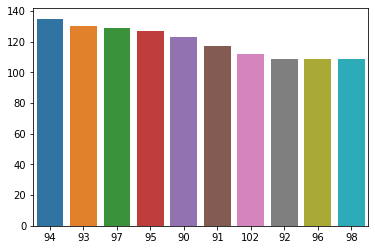

In [ ]:
sns.barplot(x=df7.index, y=df7.to_list())

# I'm really really Bad in Eda so Please Give me some tips?